**Image resizing** means changing an image from its original width and height to a fixed size.

For example, an image may originally be **1920 × 1080**, but a CNN may be designed to receive images of **224 × 224**.

Why do we resize images?

- Different images can have different sizes.
- Neural networks usually expect a consistent input size.
- Resizing makes images easier to process in batches.
- It reduces or controls computational requirements.

For example:

**Original image → 1920 × 1080**  
**Resized image → 224 × 224**

The important point is that resizing changes the **image dimensions**, but it should try to preserve the important visual information.

**Real-world example:**  
A face-recognition system may receive photos from different cameras. One photo could be 4000 × 3000 and another 1280 × 720. Before sending them to the CNN, both can be resized to the same input size.

**Important:** Resizing is not always harmless. If an image is resized too aggressively, important details can be lost. Therefore, the target size should depend on the dataset and model.

Original size: (400, 300)
Resized size: (224, 224)


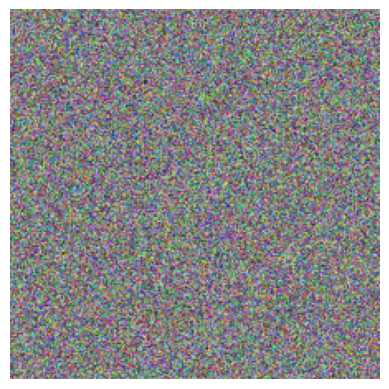

In [2]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Create a simple sample image
image_array = np.random.randint(
    0, 256, (300, 400, 3), dtype=np.uint8
)

image = Image.fromarray(image_array)

print("Original size:", image.size)

# Resize image
resized_image = image.resize((224, 224))

print("Resized size:", resized_image.size)

# Display
plt.imshow(resized_image)
plt.axis("off")
plt.show()

Image.open() → loads the image.

image.size → gives width and height.

resize((224, 224)) → changes the image to 224 × 224.

imshow() → displays the resized image.

**Image cropping** means selecting only a specific part of an image and removing the unwanted areas.

For example, suppose an image contains a person in the center but has a lot of empty background. We can crop the image to focus mainly on the person.

**Original image → Crop a selected region → Smaller focused image**

Cropping is useful when:

- The important object is only part of the image.
- We want to remove unnecessary background.
- We want the model to focus on a specific region.
- We need a fixed region or size for further processing.

**Real-world example:**  
In a face-recognition system, the original photograph may contain a person's entire body and background. The system can crop the face region before sending it to the model.

Cropping is different from resizing:

- **Resizing** changes the size of the entire image.
- **Cropping** removes unwanted parts of the image.

**Important:** Cropping should not remove important information. The correct cropping strategy depends on the dataset and the task.

Image size: (4928, 3264)


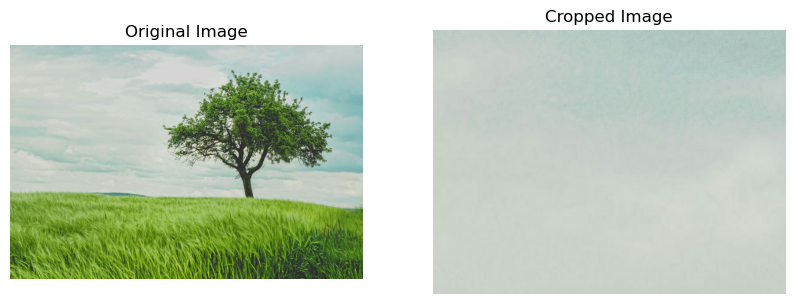

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

# Load real image
image = Image.open(
    r"C:\Users\nanda\OneDrive\Pictures\Image\johann-siemens-EPy0gBJzzZU-unsplash.jpg"
)

print("Image size:", image.size)

# Crop
cropped_image = image.crop((100, 100, 500, 400))

# Display original and cropped image
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cropped_image)
plt.title("Cropped Image")
plt.axis("off")

plt.show()


Here:

- `50, 50` → starting point `(left, top)`
- `300, 250` → ending point `(right, bottom)`
- The selected region becomes the new image.

**Image normalization** means scaling pixel values to a smaller and consistent range.

A normal image usually has pixel values between **0 and 255**.

For example:

```text
0   → Black
255 → White
128 → Gray
```

For an RGB image, each channel also has values from 0 to 255.

A common normalization is:

```text
0–255  →  0–1
```

For example:

```text
Pixel = 255 → 1.0
Pixel = 128 → 0.502
Pixel = 0   → 0.0
```

This is useful because neural networks generally work better when input values are in a smaller, consistent range.

**Real-world example:**  
Suppose a camera captures a photo of a car. The image contains thousands of pixel values between 0 and 255. Before giving the image to a neural network, we can convert those values to 0–1.

**Important:** Normalization is not the same as resizing.

- **Resizing** → changes image dimensions.
- **Normalization** → changes pixel value ranges.

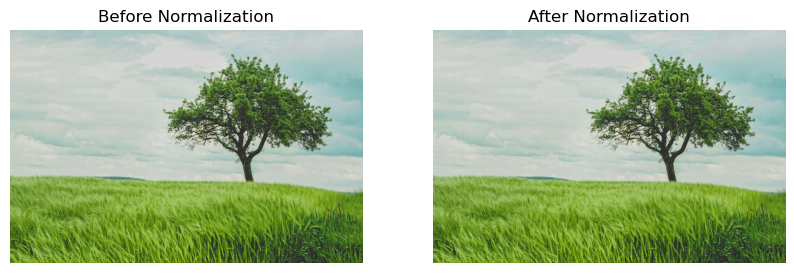

In [11]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load image
image = Image.open(
    r"C:\Users\nanda\OneDrive\Pictures\Image\johann-siemens-EPy0gBJzzZU-unsplash.jpg"
)

# Convert to NumPy array
image_array = np.array(image)

# Normalize pixels: 0-255 → 0-1
normalized_image = image_array / 255.0

# Display both images
plt.figure(figsize=(10, 4))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(image_array)
plt.title("Before Normalization")
plt.axis("off")

# Normalized image
plt.subplot(1, 2, 2)
plt.imshow(normalized_image)
plt.title("After Normalization")
plt.axis("off")

plt.show()

**Image standardization** means transforming pixel values so that they have a **mean close to 0** and a **standard deviation close to 1**.

Unlike normalization, which commonly changes:

```text
0–255 → 0–1
```

standardization uses the image's **mean and standard deviation**.

The basic idea is:

```text
Standardized value = (pixel value - mean) / standard deviation
```

After standardization:

- Mean is approximately **0**
- Standard deviation is approximately **1**
- Pixel values can be **negative or positive**

For example:

```text
Pixel value = 150
Mean = 100
Standard deviation = 25

Standardized value = (150 - 100) / 25
                  = 2
```

So standardization tells us how far a pixel value is from the average value.

**Real-world example:**  
If an image dataset contains images with different lighting conditions, standardization can help make the numerical input values more consistent before training a model.

**Important:** Normalization and standardization are different.

- **Normalization:** commonly scales values to `0–1`.
- **Standardization:** centers values around `0` with standard deviation around `1`.

Standardization is **not automatically better than normalization**. The appropriate preprocessing depends on the model and dataset.

Before standardization:
Mean: 150.1263016688683
Standard deviation: 64.10248970752014

After standardization:
Mean: -3.8600063737073604e-17
Standard deviation: 1.0


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.3419730240408487..1.636031592682874].


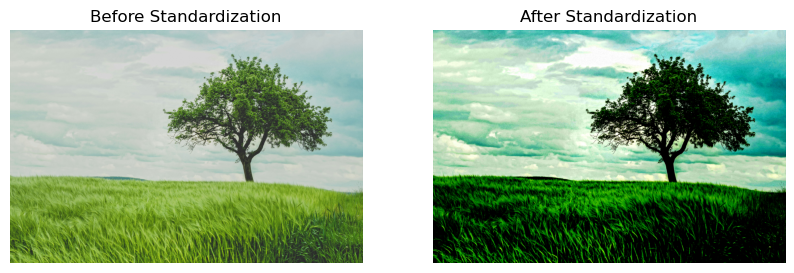

In [12]:

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load real image
image = Image.open(
    r"C:\Users\nanda\OneDrive\Pictures\Image\johann-siemens-EPy0gBJzzZU-unsplash.jpg"
)

# Convert image to NumPy array
image_array = np.array(image).astype(float)

# Calculate mean and standard deviation
mean = image_array.mean()
std = image_array.std()

# Standardize
standardized_image = (image_array - mean) / std

print("Before standardization:")
print("Mean:", image_array.mean())
print("Standard deviation:", image_array.std())

print("\nAfter standardization:")
print("Mean:", standardized_image.mean())
print("Standard deviation:", standardized_image.std())

# Display before and after
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image_array.astype(np.uint8))
plt.title("Before Standardization")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(standardized_image)
plt.title("After Standardization")
plt.axis("off")

plt.show()


```

You should see values approximately like:

```text
Before standardization:
Mean: 120.5
Standard deviation: 60.2

After standardization:
Mean: 0.0
Standard deviation: 1.0
```

The exact numbers depend on your image.

**Channel handling** means correctly working with the color channels present in an image.

Different images can have different numbers of channels:

- **Grayscale image** → 1 channel
- **RGB image** → 3 channels: Red, Green, Blue
- **RGBA image** → 4 channels: Red, Green, Blue, Alpha

For example, an RGB image is represented as:

```text
Height × Width × 3
```

The `3` represents the three color channels.

A CNN expects the correct number of channels based on its input configuration. Therefore, we need to know whether our images are grayscale, RGB, or another format before preprocessing them.

**Real-world example:**  
A chest X-ray is usually grayscale, so it may have **1 channel**. A normal photograph from a mobile phone is usually RGB, so it has **3 channels**.

**Important:** We should not blindly convert every image to RGB. The correct channel format depends on the dataset and the model.

In [13]:

from PIL import Image
import numpy as np

# Load your real image
image = Image.open(
    r"C:\Users\nanda\OneDrive\Pictures\Image\johann-siemens-EPy0gBJzzZU-unsplash.jpg"
)

# Check image mode
print("Image mode:", image.mode)

# Convert to NumPy array
image_array = np.array(image)

print("Image shape:", image_array.shape)


Image mode: RGB
Image shape: (3264, 4928, 3)


In [ ]:
```

For a normal RGB photo, you may get:

```text
Image mode: RGB
Image shape: (3000, 4000, 3)
```

Here:

```text
3000 → Height
4000 → Width
3    → RGB channels
```

You can also explicitly convert an image to RGB:

```python id="q5w5hr"
rgb_image = image.convert("RGB")

print("Mode:", rgb_image.mode)
```

This ensures the image has **3 channels**.

**Tensor conversion** means converting an image into a **PyTorch tensor** so that it can be given to a deep learning model.

An image loaded using PIL or NumPy is not automatically a PyTorch tensor.

For example:

```text
Image → NumPy array → PyTorch tensor
```

A tensor stores the image's numerical pixel values in a format that PyTorch can work with.

For an RGB image, the original NumPy shape is commonly:

```text
Height × Width × Channels
```

PyTorch models commonly expect image tensors in this order:

```text
Channels × Height × Width
```

So an image such as:

```text
300 × 400 × 3
```

becomes:

```text
3 × 300 × 400
```

**Real-world example:**  
Before sending a photograph to a PyTorch CNN for animal or human-image classification, the photograph needs to be converted into a tensor.

**Important:** Tensor conversion is different from normalization. Conversion changes the **data structure to a tensor**. Normalization changes the **pixel value range**.

In [14]:

from PIL import Image
import torch
from torchvision import transforms

# Load real image
image = Image.open(
    r"C:\Users\nanda\OneDrive\Pictures\Image\johann-siemens-EPy0gBJzzZU-unsplash.jpg"
)

# Convert image to tensor
to_tensor = transforms.ToTensor()
image_tensor = to_tensor(image)

print("Tensor shape:", image_tensor.shape)
print("Data type:", image_tensor.dtype)


Tensor shape: torch.Size([3, 3264, 4928])
Data type: torch.float32


```

For an RGB image, you may get:

```text id="c8g2fs"
Tensor shape: torch.Size([3, 3000, 4000])
Data type: torch.float32
```

Here:

```text
3    → RGB channels
3000 → Height
4000 → Width
```

`ToTensor()` also converts the usual pixel range:

```text
0–255 → 0–1
```

So the image is now ready to be used with a PyTorch model.

**Image augmentation** means creating slightly modified versions of training images so that the model sees more variety during training.

Common augmentation techniques include:

- **Rotation** → slightly rotates the image.
- **Horizontal flip** → flips the image left to right.
- **Crop** → takes a different part of the image.
- **Brightness change** → makes the image brighter or darker.
- **Resize** → changes the image size.

For example, if we have one image of a dog, augmentation can create variations of that same image:

```text
Original
   ↓
Rotate
   ↓
Flip
   ↓
Brightness change
   ↓
Different training versions
```

This can help a model learn the **important features** instead of memorizing the exact appearance of training images.

**Real-world example:**  
Suppose we are training a model to recognize dogs. Dogs may appear facing left, facing right, slightly rotated, or under different lighting conditions. Augmentation can create some of these variations during training.

**Important:** Augmentation should normally be applied to the **training data**, not blindly to validation and test data. Validation and test images should represent the real data used to evaluate the model.

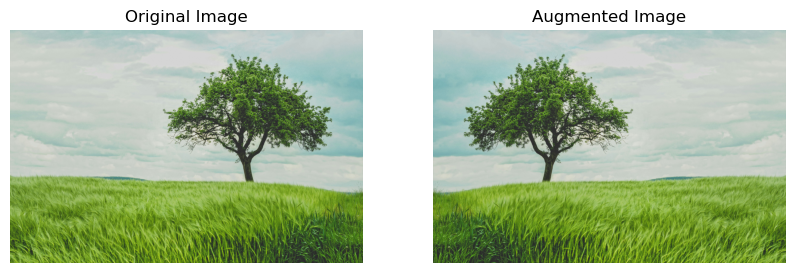

In [15]:

from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

# Load real image
image = Image.open(
    r"C:\Users\nanda\OneDrive\Pictures\Image\johann-siemens-EPy0gBJzzZU-unsplash.jpg"
)

# Create augmentation
augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1)
])

# Apply augmentation
augmented_image = augmentation(image)

# Display original and augmented image
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(augmented_image)
plt.title("Augmented Image")
plt.axis("off")

plt.show()


When working with images, we usually divide the dataset into **three parts**:

- **Training set** → used to train the model.
- **Validation set** → used to check and improve the model during development.
- **Test set** → used for the final evaluation.

The preprocessing should be handled carefully for each set.

A common approach is:

```text
Training images
→ Resize
→ Augmentation
→ Normalization
→ Tensor conversion

Validation images
→ Resize
→ Normalization
→ Tensor conversion

Test images
→ Resize
→ Normalization
→ Tensor conversion
```

The main difference is **augmentation**.

We normally use augmentation on the **training set** because we want to create useful variations for learning.

We generally do **not** randomly augment validation and test images because we want to evaluate the model on consistent, realistic data.

**Real-world example:**  
Suppose we are training a model to classify cats and dogs.

- Training → images can be flipped or slightly rotated.
- Validation → use the normal images after required preprocessing.
- Test → use the normal images after required preprocessing.

This gives us a fair idea of how the model performs on unseen images.

In [16]:

from torchvision import transforms

# Training preprocessing
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation preprocessing
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Test preprocessing
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


```

The important difference is:

```text
Training   → Resize + Augmentation + Tensor + Normalization
Validation → Resize + Tensor + Normalization
Test       → Resize + Tensor + Normalization
```

This prevents random augmentation from affecting validation and test evaluation.

# 9. Why Preprocessing Should Not Be Applied Blindly
There is **no single preprocessing method that is correct for every image dataset**.

The preprocessing should depend on:

- **Type of images** — RGB, grayscale, medical images, satellite images, etc.
- **Dataset size and quality**
- **Model being used**
- **Image resolution**
- **Meaning of the image information**

For example:

**RGB photographs**

```text
Resize → Tensor → Normalize
```

may be appropriate.

**Grayscale X-ray images**

```text
Resize → Handle 1 channel → Tensor → Normalize
```

may be more appropriate.

Similarly, augmentation must match the problem.

For example, horizontal flipping may be useful for some animal images, but it may be inappropriate when the direction of an object has meaning.

Therefore, we should always ask:

**"What information does this dataset contain, and what preprocessing does the model actually need?"**

The main idea is:

> **Do not apply preprocessing just because it is commonly used. Choose preprocessing based on the dataset and the task.**